In [1]:
# ------------------------------------------------------------
# 🔧 Sistema y utilidades
# ------------------------------------------------------------
import os
import time
import random
import zipfile
import urllib

# ------------------------------------------------------------
# 🔢 Cálculo numérico y científico
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import scipy.ndimage as ndi
from scipy.ndimage import gaussian_filter
from math import log10

# ------------------------------------------------------------
# 🎨 Visualización
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 🖼️ Procesamiento de imágenes
# ------------------------------------------------------------
from PIL import Image
from skimage import io
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 🧠 Machine Learning / Deep Learning
# ------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from torchsummary import summary

# ------------------------------------------------------------
# 🌀 Librerías adicionales para operadores y modelos avanzados
# ------------------------------------------------------------
from einops import rearrange
from neuralop.models import FNO
from tqdm import tqdm

# ------------------------------------------------------------
# 📦 Librerías del paquete The Well
# ------------------------------------------------------------
from the_well.data import WellDataset
from the_well.benchmark.metrics import VRMSE
from the_well.utils.download import well_download

# ------------------------------------------------------------
# 🖼️ Vision por computador (torchvision)
# ------------------------------------------------------------
from torchvision import datasets, transforms
# ------------------------------------------------------------



In [2]:
test_dataset = WellDataset(
    well_base_path="/home/itachi/Desktop/msc/data/datasets",
    well_dataset_name="active_matter",
    well_split_name="test",
    n_steps_input=1,
    n_steps_output=0,
    use_normalization=True,

)

In [3]:
print(len(test_dataset))
item = test_dataset[0]

2106


In [4]:
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f"Test samples: {len(test_dataset)}")

Test samples: 2106


In [5]:
class AE(nn.Module):
    def __init__(self, latent_dim=256):
        super(AE, self).__init__()

        # -------------- ENCODER --------------
        self.encoder_conv = nn.Sequential(
            # 256 -> 128
            nn.Conv2d(11, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 128 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 64 -> 32
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  
            # 32 -> 16
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), 
        )
        
        self.enc_out_channels = 256
        self.enc_out_h = 16
        self.enc_out_w = 16
        enc_flat_dim = self.enc_out_channels * self.enc_out_h * self.enc_out_w

        # Cuello de botella
        self.fc_enc = nn.Linear(enc_flat_dim, latent_dim)

        # -------------- DECODER --------------
        self.fc_dec = nn.Linear(latent_dim, enc_flat_dim)

        self.decoder_conv = nn.Sequential(
            # 16 -> 32
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # 32 -> 64
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # 64 -> 128
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # 128 -> 256
            nn.ConvTranspose2d(32, 11, kernel_size=3, stride=2, padding=1, output_padding=1),
            #nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)                  
        h = h.view(x.size(0), -1)                 
        z = self.fc_enc(h)                        
        return z

    def decode(self, z):
        h = self.fc_dec(z)                        
        h = h.view(-1, self.enc_out_channels, self.enc_out_h, self.enc_out_w)  
        xr = self.decoder_conv(h)                 
        return xr

    def forward(self, x):
        z = self.encode(x)
        xr = self.decode(z) # xr shape: (Batch, 11, H, W)
        
        # Separamos las salidas
        out_conc = xr[:, 0:1, :, :]  # Canal 0
        out_vel  = xr[:, 1:, :, :]   # Canales 1-10
        
        # Aplicamos activaciones específicas
        out_conc = torch.sigmoid(out_conc)  # Fuerza rango [0, 1] para densidad
        out_vel  = torch.tanh(out_vel)      # Fuerza rango [-1, 1] para velocidad
        
        # Unimos de nuevo
        return torch.cat([out_conc, out_vel], dim=1), z


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AE().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-8)

In [7]:
# map_location ayuda si guardaste en GPU y ahora cargas en CPU o viceversa
state_dict = torch.load("3model_v0.pth", map_location=device, weights_only=True)

# --- PASO CLAVE: LIMPIEZA DE PREFIJOS DE TORCH.COMPILE ---
# Crea un diccionario nuevo limpiando el prefijo "_orig_mod." si existe
new_state_dict = {}
for key, value in state_dict.items():
    # Si se guardó compilado, las keys se ven así: "_orig_mod.encoder_conv.0.weight"
    # Necesitamos que sean: "encoder_conv.0.weight"
    new_key = key.replace("_orig_mod.", "")
    new_state_dict[new_key] = value

    # 4. Cargar los pesos limpios al modelo
model.load_state_dict(new_state_dict)
print("✅ Modelo cargado exitosamente (Prefijos de compilación corregidos).")

✅ Modelo cargado exitosamente (Prefijos de compilación corregidos).


In [8]:
# model = AE()
# model.load_state_dict(torch.load("model_0.pth"))
model.to(device)
model.eval()

AE(
  (encoder_conv): Sequential(
    (0): Conv2d(11, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_enc): Linear(in_features=65536, out_features=256, bias=True)
  (fc_dec): Linear(in_features=256, out_features=65536, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_

In [9]:
def preprocess_batch(batch, device):
    """
    Normalización Adaptativa para Alto Contraste:
    - Densidad: Se expande el rango [0.9, 1.0] -> [0, 1]
    - Velocidad: Se escala [-max, +max] -> [-1, 1]
    """
    # 1. Cargar y ajustar dimensiones
    # (B, 1, 256, 256, 11) -> (B, 256, 256, 11)
    x = batch["input_fields"].to(device, non_blocking=True).squeeze(1) 

    # ============================================================
    # --- PARTE A: Normalizar Concentración (Canal 0) -> [0, 1] ---
    # ============================================================
    conc = x[..., 0:1] # (B, 256, 256, 1)
    
    # 1. SEGURIDAD: Eliminamos valores negativos (ruido numérico)
    # Al hacer esto, el mínimo posible se vuelve 0.0.
    conc = torch.clamp(conc, min=0.0) 
    
    # 2. Aplanamos espacialmente para encontrar min/max de CADA imagen individual
    conc_flat = conc.view(conc.size(0), -1)
    
    # 3. Calculamos min y max reales de la imagen (ej: 0.998 y 1.002)
    # Como ya hicimos clamp, cmin está garantizado de ser >= 0
    cmin = conc_flat.min(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
    cmax = conc_flat.max(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
    
    # 4. Normalización Min-Max [0, 1]
    # (Valor - Min) / (Max - Min)
    # epsilon evita división por cero si la imagen es plana
    epsilon = 1e-7
    denom = (cmax - cmin) + epsilon
    
    conc_norm = (conc - cmin) / denom

    # ============================================================
    # --- PARTE B: Normalizar Velocidades -> [-1, 1] ---
    # ============================================================
    vel = x[..., 1:] # (B, 256, 256, 10)
    vel_flat = vel.reshape(vel.size(0), -1)
    
    # Buscamos la magnitud máxima para escalar
    vmax_abs = vel_flat.abs().max(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
    
    # Normalización [-1, 1]
    vel_norm = vel / (vmax_abs + epsilon)

    # ============================================================
    # --- PARTE C: Reconstruir y Permutar ---
    # ============================================================
    x_final = torch.cat([conc_norm, vel_norm], dim=-1)
    
    # Cambiar a formato (Batch, Channel, H, W) para la red
    x_final = x_final.permute(0, 3, 1, 2).contiguous() 
    
    return x_final

In [10]:
# xti = []
# xto = []
ze = []
with torch.no_grad():
    for batch in test_loader:
        # x = batch["input_fields"].to(device)
        
        # x = x[:, 0]                       # (B, 256, 256, 11)
        # x = x.permute(0, 3, 1, 2).contiguous()  # (B, 11, 256, 256)

        x = preprocess_batch(batch, device)
        #xti.append(x)
        xr, z = model(x)
        ze.append(z.cpu())
        #xto.append(xr)
        #val_loss = criterion(xr, x)




In [11]:
print(x.shape, xr.shape)

torch.Size([58, 11, 256, 256]) torch.Size([58, 11, 256, 256])


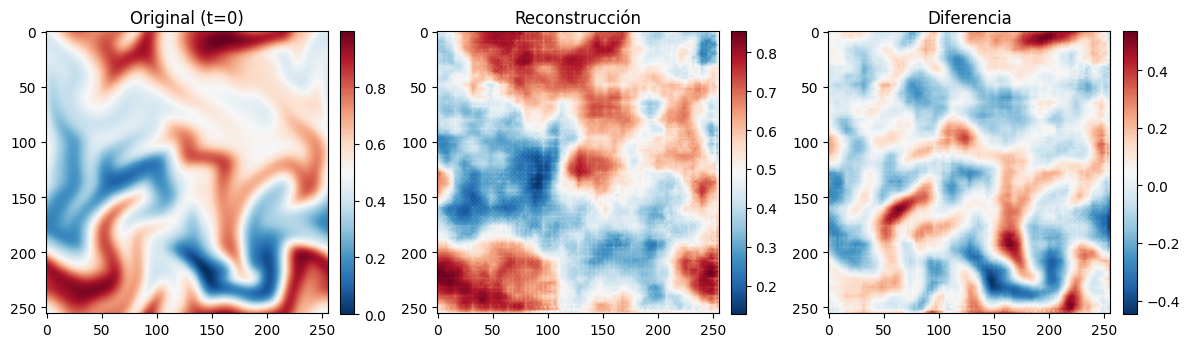

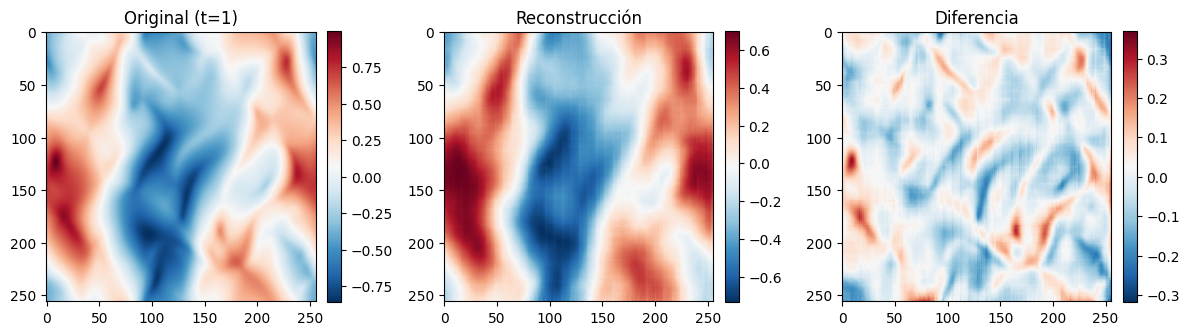

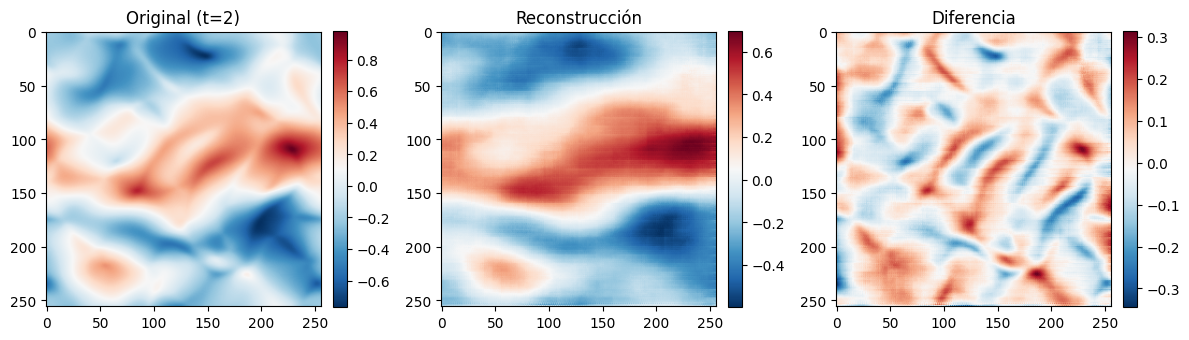

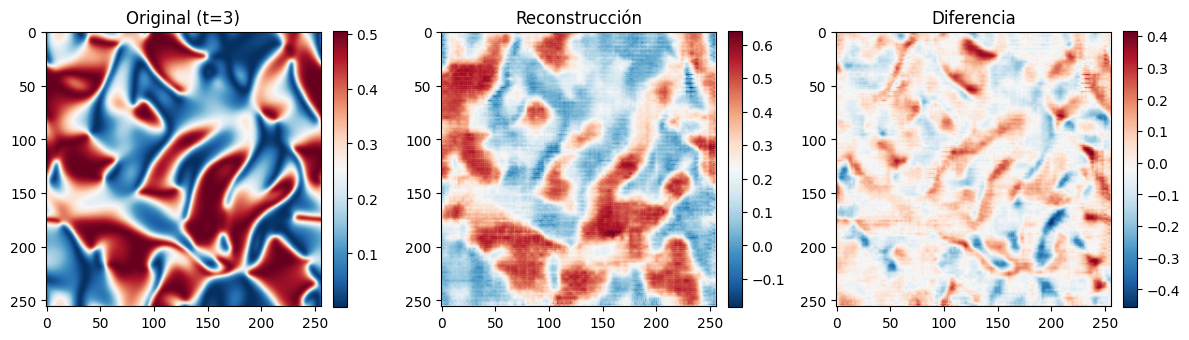

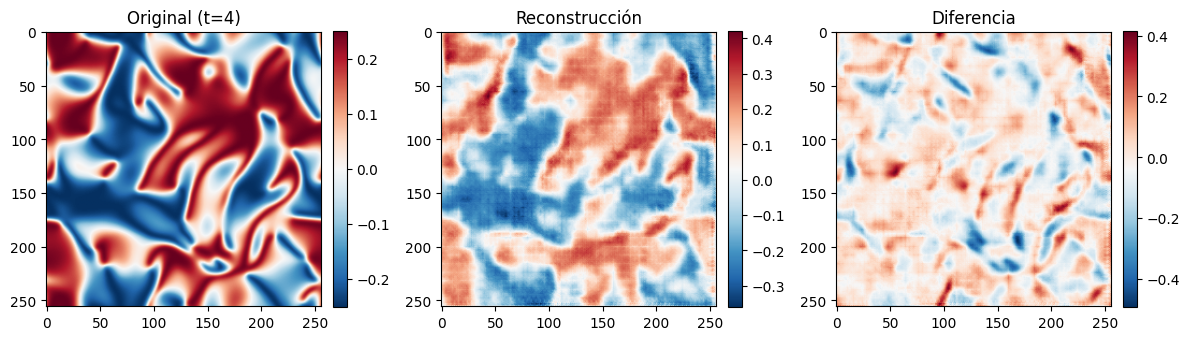

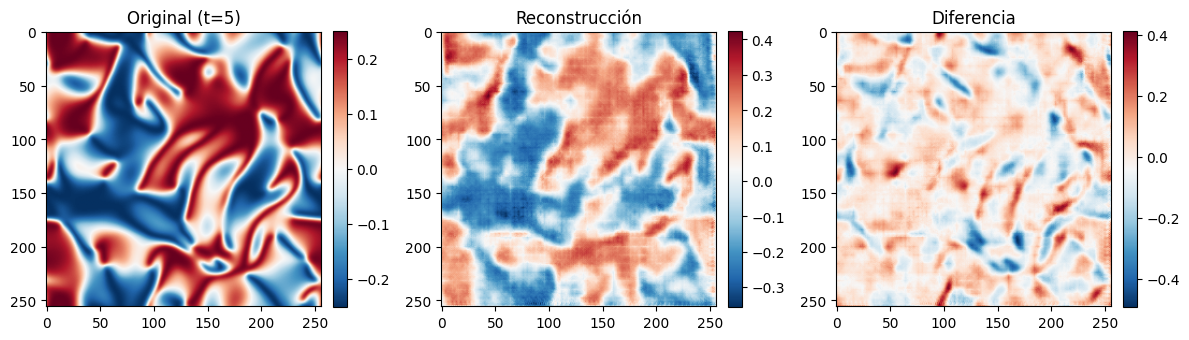

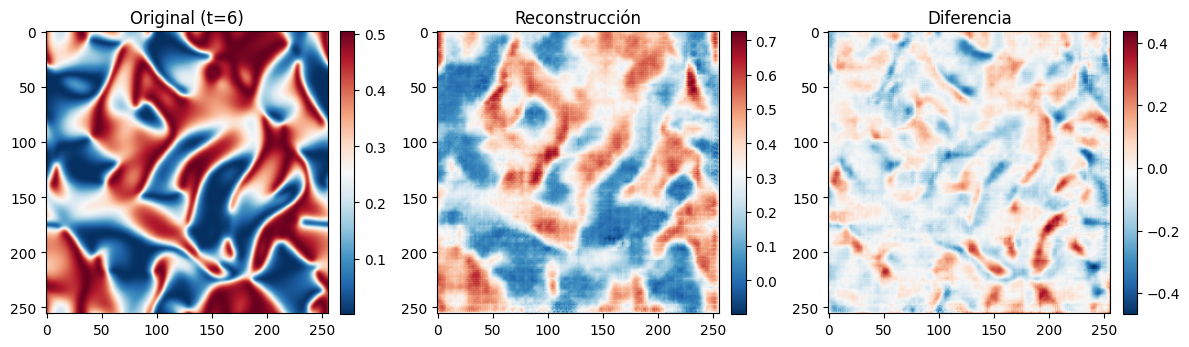

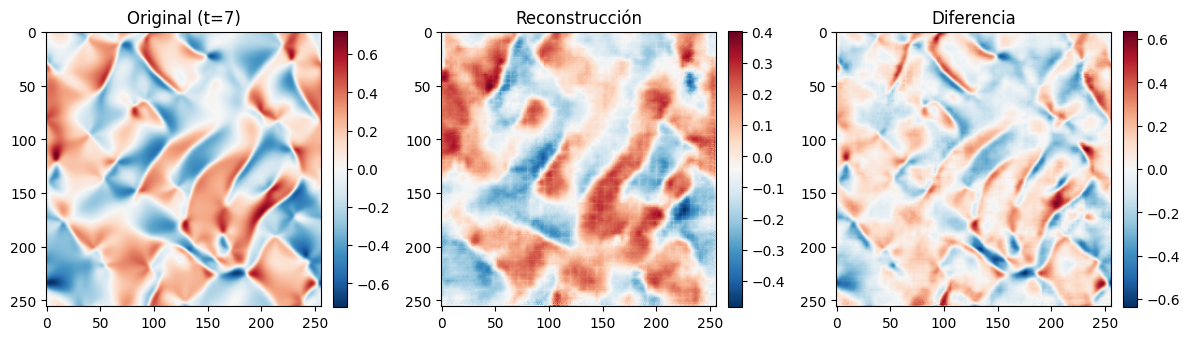

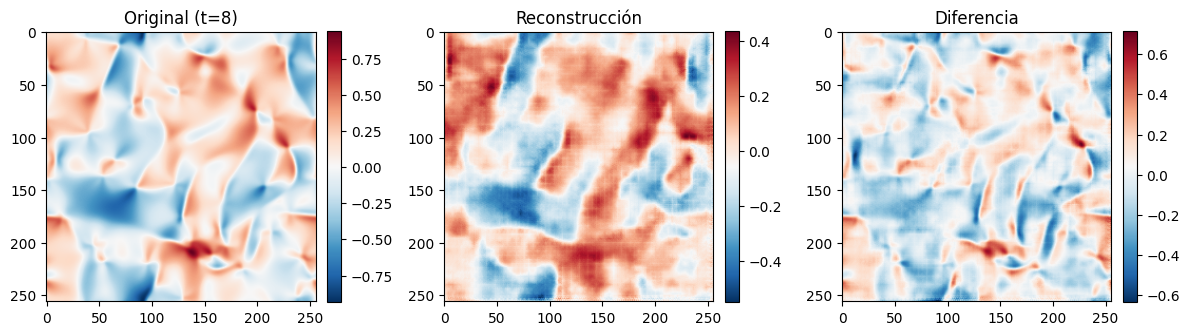

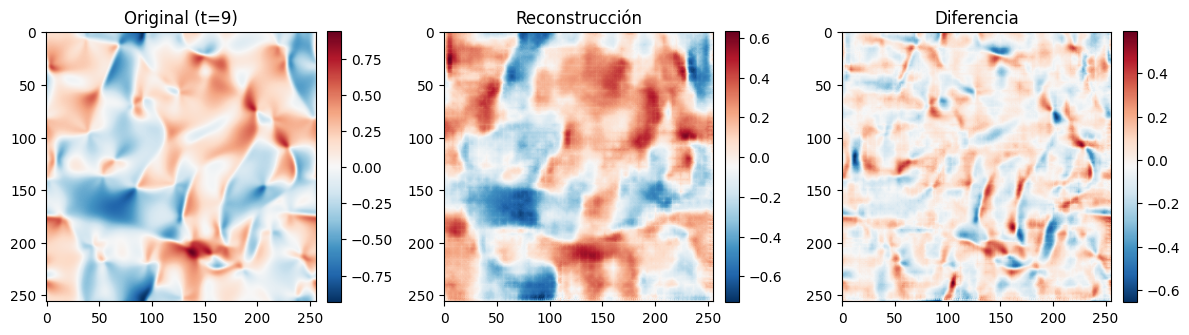

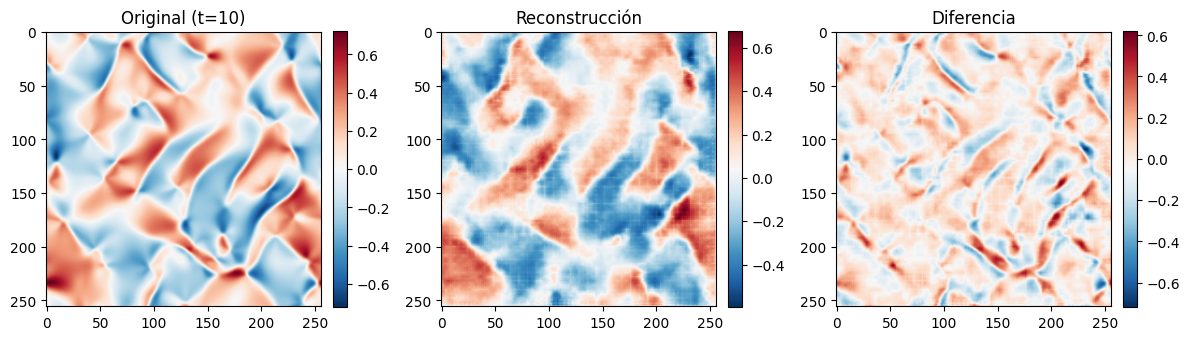

In [12]:
sim = 2
#import matplotlib.pyplot as plt

# Asumiendo que 'x', 'xr' y 'sim' ya están definidos en tu entorno

for i in range(11):
    img = x[sim, i, :, :].detach().cpu().numpy() 
    imgr = xr[sim, i, :, :].detach().cpu().numpy() 
    
    # Aumenté un poco el ancho (de 8 a 12) para que las barras quepan cómodamente
    plt.figure(figsize=(12, 4))

    # --- Imagen Original ---
    plt.subplot(1, 3, 1)
    plt.title(f"Original (t={i})")
    im1 = plt.imshow(img, cmap="RdBu_r")
    # fraction=0.046 y pad=0.04 son valores 'mágicos' para alinear la barra al tamaño del plot
    plt.colorbar(im1, fraction=0.046, pad=0.04)

    # --- Imagen Reconstruida ---
    plt.subplot(1, 3, 2)
    plt.title("Reconstrucción")
    im2 = plt.imshow(imgr, cmap="RdBu_r")
    plt.colorbar(im2, fraction=0.046, pad=0.04)

    # --- Diferencia (Error) ---
    plt.subplot(1, 3, 3)
    plt.title("Diferencia")
    im3 = plt.imshow(img - imgr, cmap="RdBu_r")
    plt.colorbar(im3, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

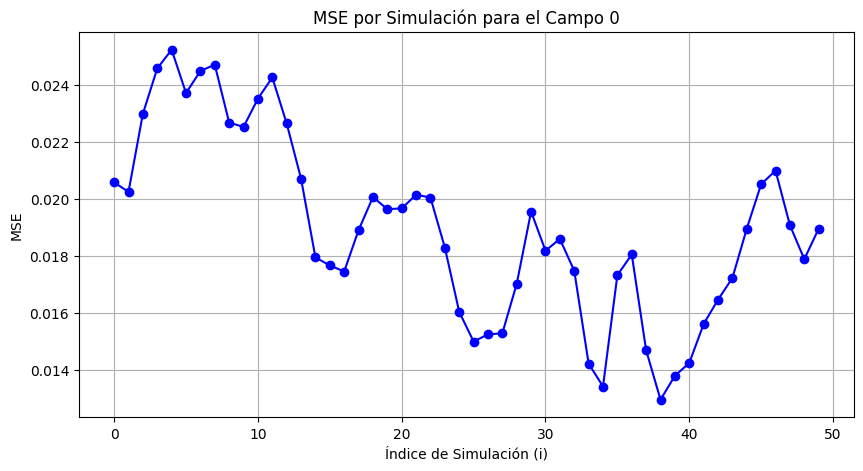

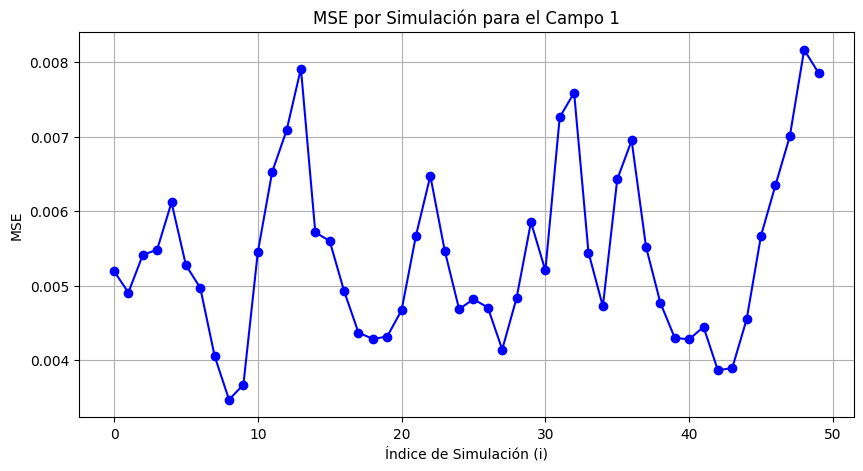

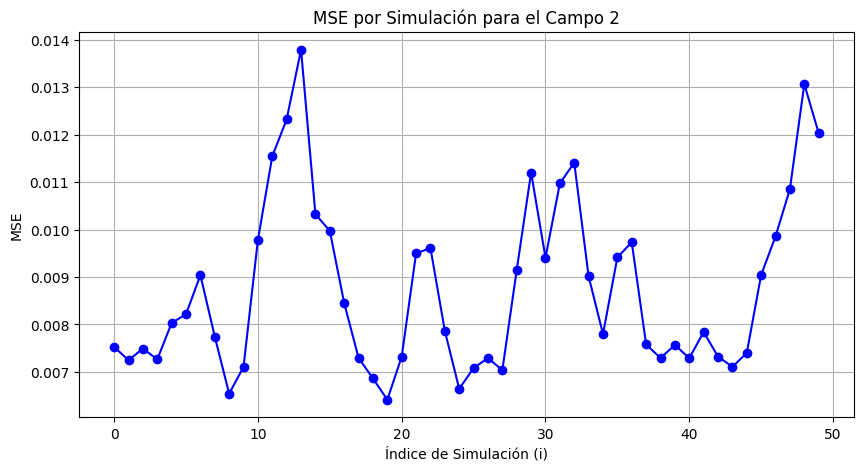

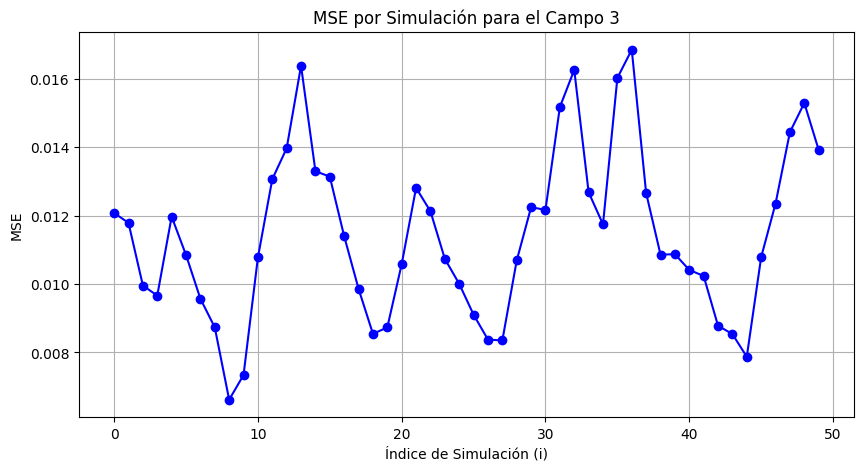

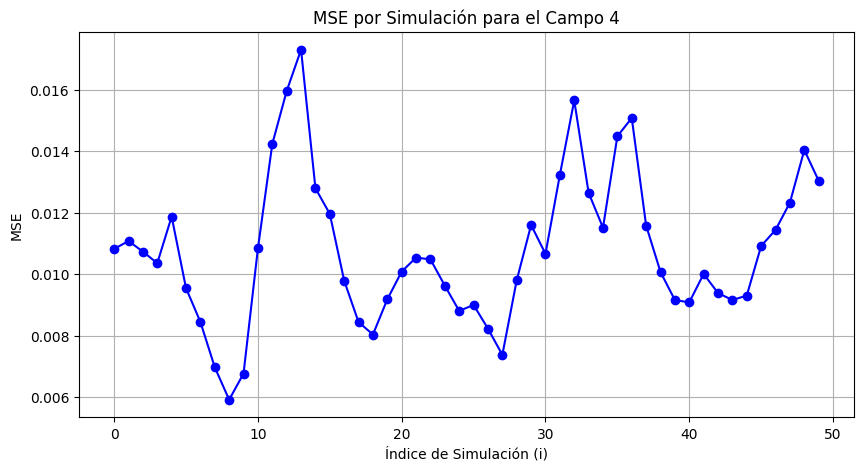

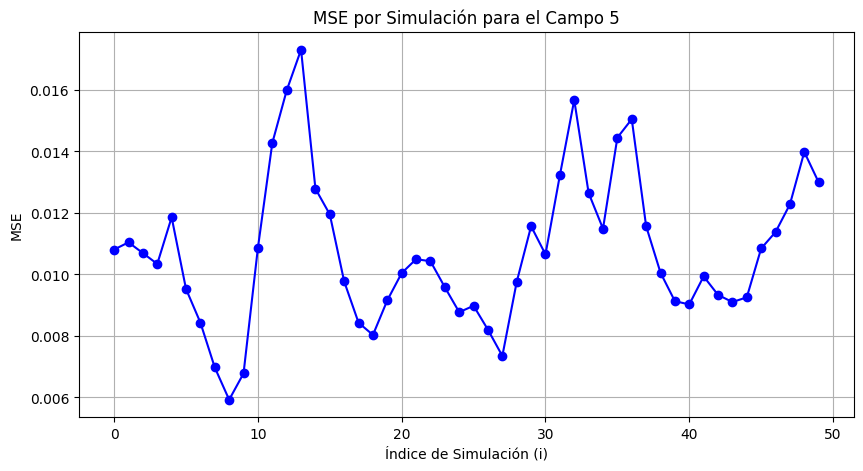

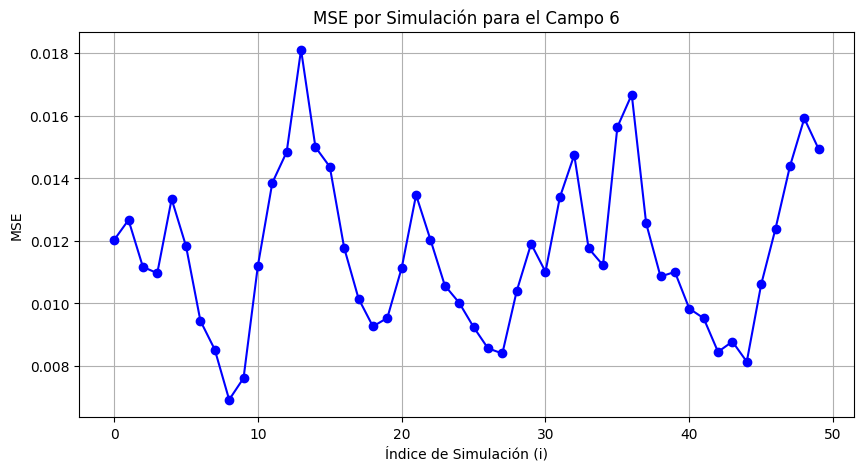

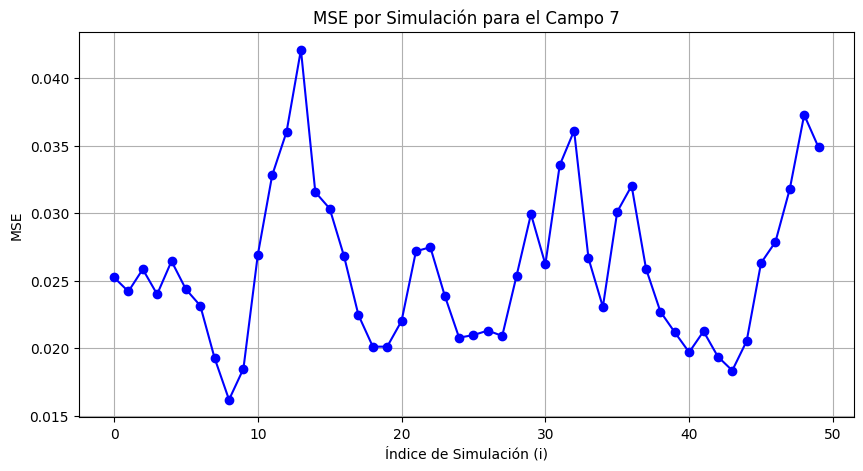

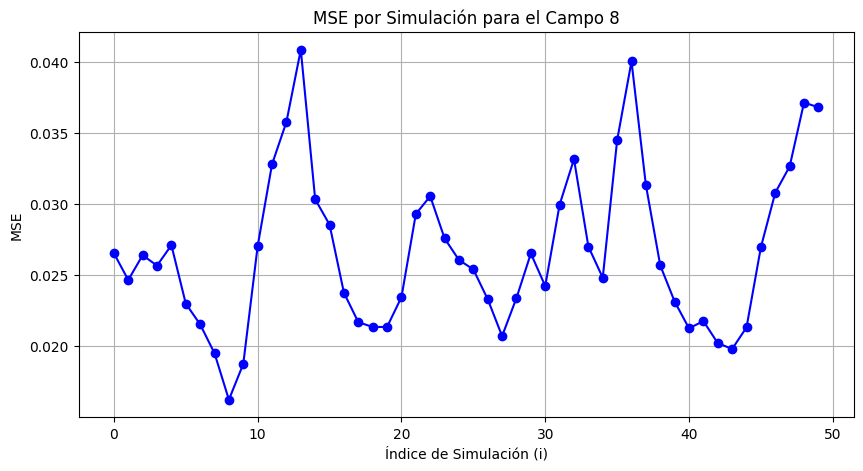

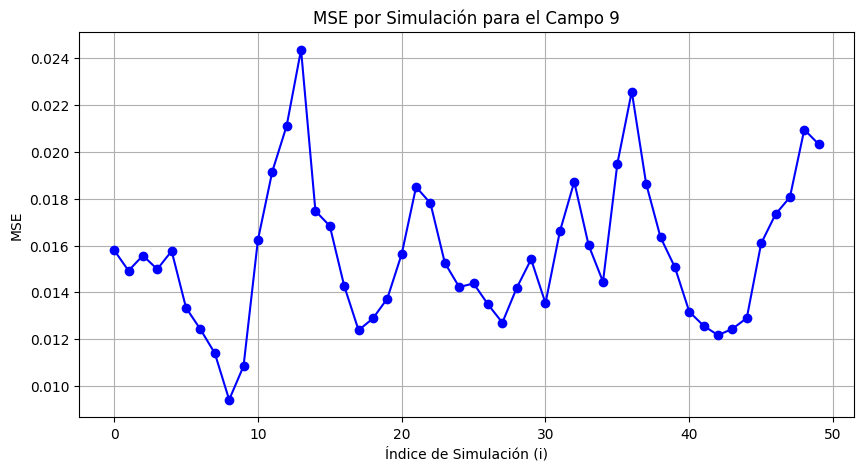

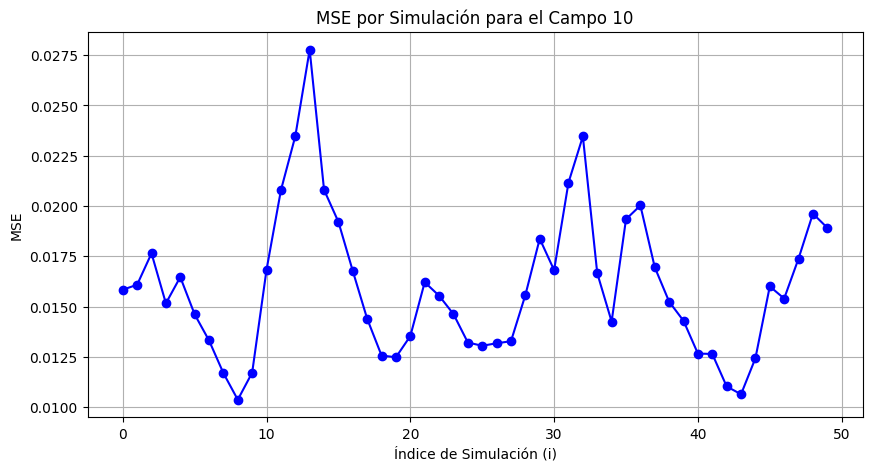

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Definiciones y Inicialización Corregida ---
# 50 corresponde a cada batch de test.

N_SAMPLES = 50   # Dimensión 'i' (Número de Simulaciones/Muestras)
N_FIELDS = 11    # Dimensión 'j' (Número de Campos/Canales)

# La matriz MSE debe ser (Simulaciones x Campos) -> (50 x 11)
mse = np.zeros((N_SAMPLES, N_FIELDS)) 


# El orden de los bucles se ajusta a cómo se usa la matriz mse[i, j]
for j in range(N_FIELDS): # j: 0 a 10 (Iterando sobre cada Campo)
    for i in range(N_SAMPLES): # i: 0 a 49 (Iterando sobre cada Simulación)
        
        # Extracción: x[Simulación (i), Campo (j), :, :]
        img = x[i, j, :, :].detach().cpu().numpy() 
        imgr = xr[i, j, :, :].detach().cpu().numpy() 
        
        # Asignación: mse[Simulación (i), Campo (j)]
        mse[i, j] = np.mean((img - imgr) ** 2)

    plt.figure(figsize=(10, 5))
    plt.plot(mse[:, j], marker='o', linestyle='-', color='blue')
    plt.title(f"MSE por Simulación para el Campo {j}")
    plt.xlabel("Índice de Simulación (i)")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.show()



In [14]:
# # Asumo que 'sim' es el índice del batch que quieres ver (ej. sim = 0)
# sim = 0 

# # Nombres de canales (Opcional: ayuda a saber qué estás viendo)
# channel_names = ["Densidad", "Vx", "Vy", "Sxx", "Sxy", "Syr", "...", "...", "...", "...", "..."]

# for i in range(11):
#     # Extraemos los arrays numpy
#     img = x[sim, i, :, :].detach().cpu().numpy() 
#     imgr = xr[sim, i, :, :].detach().cpu().numpy() 
    
#     # 1. TRUCO CLAVE: Calcular min/max GLOBAL de la imagen original
#     # Usaremos estos límites para AMBAS gráficas. Así el color "Rojo" significa lo mismo en las dos.
#     g_min = img.min()
#     g_max = img.max()
    
#     # Para la diferencia, lo ideal es centrarla en 0
#     diff = img - imgr
#     diff_max = np.abs(diff).max() # Para que el rango sea simétrico (ej -0.1 a +0.1)

#     plt.figure(figsize=(14, 4))

#     # --- Imagen Original ---
#     plt.subplot(1, 3, 1)
#     # Si tienes nombres, úsalos, si no, pon el índice
#     title = channel_names[i] if i < len(channel_names) else f"Canal {i}"
#     plt.title(f"Original: {title}")
    
#     # vmin/vmax forzados
#     im1 = plt.imshow(img, cmap="RdBu_r", vmin=g_min, vmax=g_max)
#     plt.colorbar(im1, fraction=0.046, pad=0.04)

#     # --- Imagen Reconstruida ---
#     plt.subplot(1, 3, 2)
#     plt.title("Reconstrucción (Predicción)")
#     # IMPORTANTE: Usamos g_min y g_max de la original aquí también
#     im2 = plt.imshow(imgr, cmap="RdBu_r", vmin=g_min, vmax=g_max)
#     plt.colorbar(im2, fraction=0.046, pad=0.04)

#     # --- Diferencia (Error) ---
#     plt.subplot(1, 3, 3)
#     plt.title("Mapa de Error (Orig - Pred)")
#     # Para diferencias, 'seismic' o 'bwr' son buenos porque el blanco es 0 exacto
#     im3 = plt.imshow(diff, cmap="seismic", vmin=-diff_max, vmax=diff_max)
#     plt.colorbar(im3, fraction=0.046, pad=0.04)

#     plt.tight_layout()
#     plt.show()

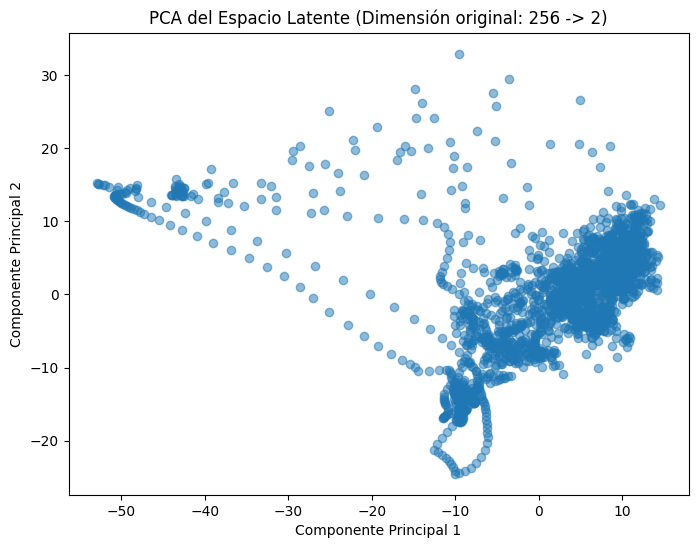

In [15]:
from sklearn.decomposition import PCA
Z_tensor = torch.cat(ze, dim=0)

# 2. Convertir a Numpy
X = Z_tensor.numpy()

# 3. Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 4. Graficar
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title(f"PCA del Espacio Latente (Dimensión original: {X.shape[1]} -> 2)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

In [16]:

N = 2106
T = 1

for i in range(N):

    item = test_dataset[i]
    x    = item['input_fields']  
    x_c = item['constant_scalars']

In [17]:
#xc = x_c.flatten()
print(x_c[0])

tensor(10.)


In [18]:


N = 2106
T = 1

mc = np.zeros((N, T), dtype=np.float32)
Ke = np.zeros((N, T), dtype=np.float32)
S = np.zeros((N, T), dtype=np.float32)
Srm = np.zeros((N, T), dtype=np.float32)
N_o = np.zeros((N, T), dtype=np.float32)
C_c = np.zeros((N, T), dtype=np.float32)
cons_scal1 = np.zeros((N, T), dtype=np.float32)
cons_scal2 = np.zeros((N, T), dtype=np.float32)
cons_scal3 = np.zeros((N, T), dtype=np.float32)

for i in range(N):

    item = test_dataset[i]
    x    = item['input_fields'] 
    x_c = item['constant_scalars'] 

    for t in range(T):
        
        c  = x[t, :, :, 0].mean()

        vx = x[t, :, :, 1]
        vy = x[t, :, :, 2]
        ke = 0.5 * ( (vx**2 + vy**2).mean() )

        Lx, Ly = vx.shape
        Lx_phys = 10.0
        Ly_phys = 10.0

        dx = Lx_phys / Lx
        dy = Ly_phys / Ly


        dvy_dx = np.gradient(vy, dx, axis=-2)  # ∂x v_y
        dvx_dy = np.gradient(vx, dy, axis=-1) 

        dxx = x[t, :, :, 3]
        dxy = x[t, :, :, 4]
        dyx = x[t, :, :, 5]
        dyy = x[t, :, :, 6]
        Si = (( dvy_dx - dvx_dy)**2).mean()

        Exx = x[t, :, :, 7]
        Exy = x[t, :, :, 8]
        Eyx = x[t, :, :, 9]
        Eyy = x[t, :, :, 10]
        smr = np.sqrt(Exx**2 + 2*Exy*Eyx + Eyy**2).mean()
        no = np.sqrt(dxx**2 + dxy**2 + dyx**2 + dyy**2).mean()

        cc = (vx*dxx + vy*dyx).mean()


        cons_scal1[i, t] = x_c[0]
        cons_scal2[i, t] = x_c[1]
        cons_scal3[i, t] = x_c[2]

        #print('c0' , cons_scal1[i, t],'c1',cons_scal2[i, t],'c2', cons_scal3[i, t])
        mc[i, t] = c
        #print('mc',mc[i, t])
        Ke[i, t] = ke
        S[i,t] = Si
        Srm[i,t] = smr
        N_o[i,t] = no
        C_c[i,t] = cc

/tmp/ipykernel_39308/2156112009.py:49: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  smr = np.sqrt(Exx**2 + 2*Exy*Eyx + Eyy**2).mean()
/tmp/ipykernel_39308/2156112009.py:50: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  no = np.sqrt(dxx**2 + dxy**2 + dyx**2 + dyy**2).mean()


In [19]:
mc_flat = mc.flatten()
Ke_flat = Ke.flatten() 
S_flat = S.flatten()
Srm_flat = Srm.flatten()    
No_flat = N_o.flatten()
C_c_flat = C_c.flatten()
cons_scal1 = cons_scal1.flatten()
cons_scal2 = cons_scal2.flatten()
cons_scal3 = cons_scal3.flatten()


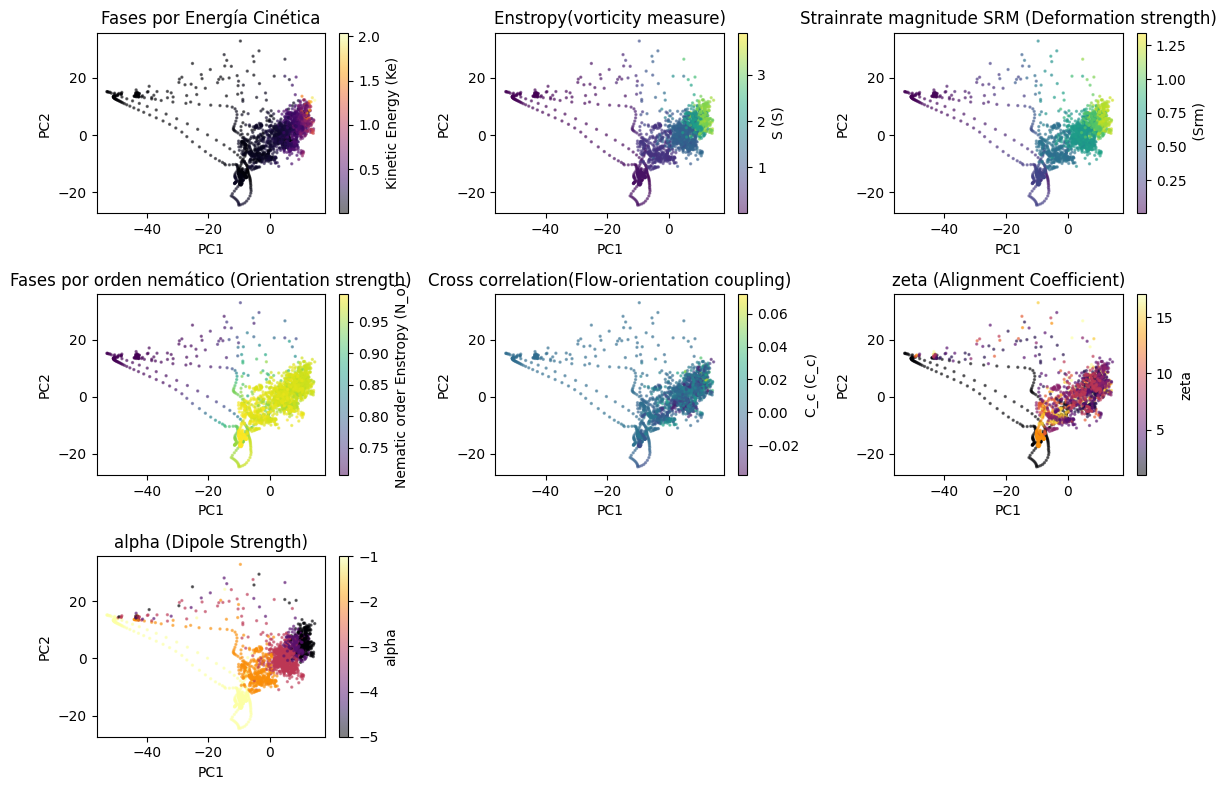

In [20]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 3, 1)
sc1 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Ke_flat, cmap='inferno', s=2, alpha=0.5)
plt.colorbar(sc1, label='Kinetic Energy (Ke)')
plt.title("Fases por Energía Cinética")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Graficar: Colorear por Enstrofia (N_o) u otro parámetro
plt.subplot(3, 3, 2)
sc2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=S_flat, cmap='viridis', s=2, alpha=0.5)
plt.colorbar(sc2, label='S (S)')
plt.title("Enstropy(vorticity measure)") #escalar derivado del tensor de deformacion
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 3)
sc2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Srm_flat, cmap='viridis', s=2, alpha=0.5)
plt.colorbar(sc2, label=' (Srm)')
plt.title("Strainrate magnitude SRM (Deformation strength)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 4)
sc2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=No_flat, cmap='viridis', s=2, alpha=0.5)
plt.colorbar(sc2, label='Nematic order Enstropy (N_o)')
plt.title("Fases por orden nemático (Orientation strength)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 5)
sc2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=C_c_flat, cmap='viridis', s=2, alpha=0.5)
plt.colorbar(sc2, label='C_c (C_c)')
plt.title("Cross correlation(Flow-orientation coupling)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 6)
sc1 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cons_scal2, cmap='inferno', s=2, alpha=0.5)
plt.colorbar(sc1, label='zeta')
plt.title("zeta (Alignment Coefficient)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 7)
sc1 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cons_scal3, cmap='inferno', s=2, alpha=0.5)
plt.colorbar(sc1, label='alpha')
plt.title("alpha (Dipole Strength)")
plt.xlabel("PC1")
plt.ylabel("PC2")


plt.tight_layout()
plt.show()

In [21]:
import umap
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler


2025-12-08 20:35:56.232735: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-08 20:35:56.260230: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-08 20:35:56.919129: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [27]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)


reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(scaled_data)

# 
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=Ke_flat, cmap='Spectral', s=5, alpha=0.8)
# plt.colorbar(scatter, label='Kinetic Energy (Ke)')
# #plt.colorbar(scatter, boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
# plt.title('UMAP Projection of Digits Dataset')
# plt.xlabel('UMAP 1')
# plt.ylabel('UMAP 2')
# plt.grid(True, alpha=0.3)
# plt.show()


/home/itachi/miniconda3/envs/ml/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


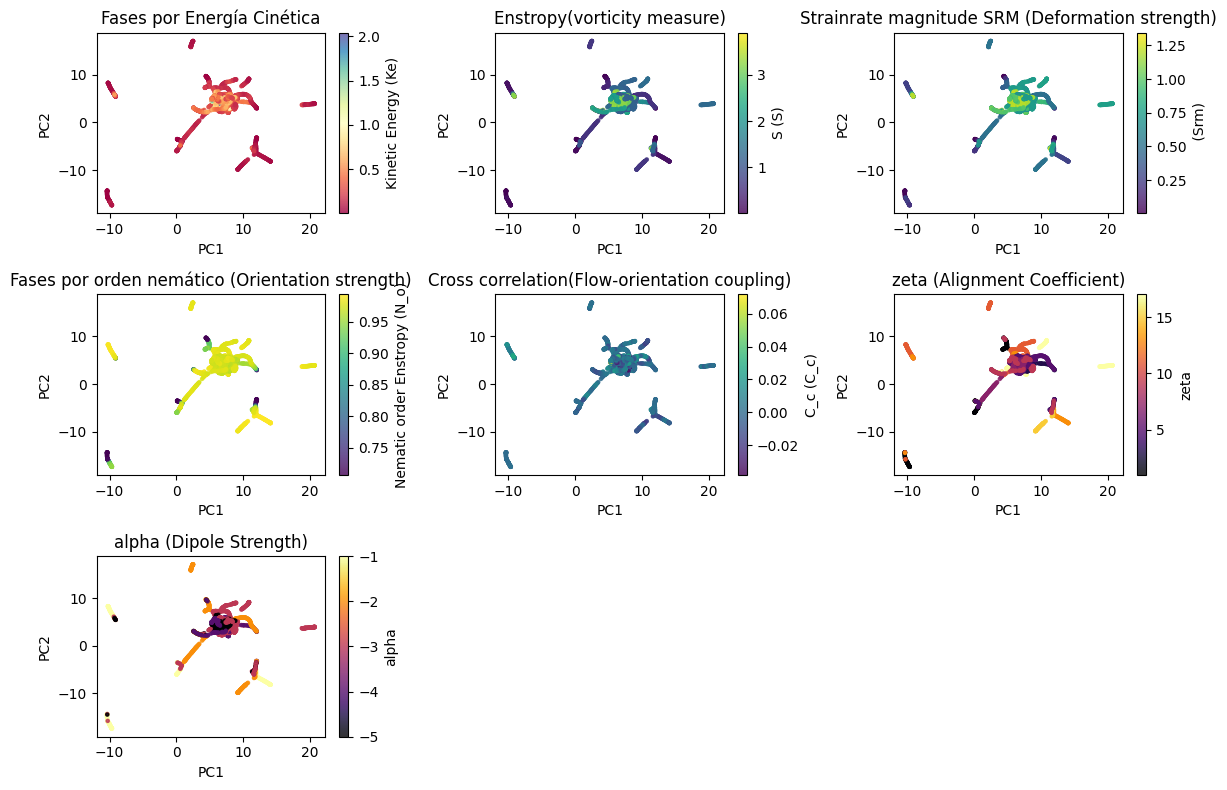

In [28]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 3, 1)
sc1 = plt.scatter(embedding[:, 0], embedding[:, 1], c=Ke_flat, cmap='Spectral', s=5, alpha=0.8)
plt.colorbar(sc1, label='Kinetic Energy (Ke)')
plt.title("Fases por Energía Cinética")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Graficar: Colorear por Enstrofia (N_o) u otro parámetro
plt.subplot(3, 3, 2)
sc2 = plt.scatter(embedding[:, 0], embedding[:, 1], c=S_flat, cmap='viridis', s=5, alpha=0.8)
plt.colorbar(sc2, label='S (S)')
plt.title("Enstropy(vorticity measure)") #escalar derivado del tensor de deformacion
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 3)
sc2 = plt.scatter(embedding[:, 0], embedding[:, 1], c=Srm_flat, cmap='viridis', s=5, alpha=0.8)
plt.colorbar(sc2, label=' (Srm)')
plt.title("Strainrate magnitude SRM (Deformation strength)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 4)
sc2 = plt.scatter(embedding[:, 0], embedding[:, 1], c=No_flat, cmap='viridis', s=5, alpha=0.8)
plt.colorbar(sc2, label='Nematic order Enstropy (N_o)')
plt.title("Fases por orden nemático (Orientation strength)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 5)
sc2 = plt.scatter(embedding[:, 0], embedding[:, 1], c=C_c_flat, cmap='viridis', s=5, alpha=0.8)
plt.colorbar(sc2, label='C_c (C_c)')
plt.title("Cross correlation(Flow-orientation coupling)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 6)
sc2 = plt.scatter(embedding[:, 0], embedding[:, 1], c=cons_scal2, cmap='inferno', s=5, alpha=0.8)

plt.colorbar(sc2, label='zeta')
plt.title("zeta (Alignment Coefficient)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(3, 3, 7)
sc1 = plt.scatter(embedding[:, 0], embedding[:, 1], c=cons_scal3, cmap='inferno', s=5, alpha=0.8)
plt.colorbar(sc1, label='alpha')
plt.title("alpha (Dipole Strength)")
plt.xlabel("PC1")
plt.ylabel("PC2")


plt.tight_layout()
plt.show()